<a href="https://colab.research.google.com/github/samueltuiransierra-cmyk/PROG_CIVIL_2026_1/blob/main/dise%C3%B1o_y_evaluaci%C3%B3n_de_canales_abiertos_para_el_transporte_de_agua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Prog_Trabajo_Aplicado_Func_Estructuras_Gemini**.



Curso: Programación de Computadores con Python

Ingeniería Civil

ESTUDIANTES:

SAMUEL TUIRAN SIERRA   1104261565

CARLOS JOSÉ MONTERROZA BUELVAS   1064608247

LUIS MARIO MENCO GAVIRIA    1102581531


## Resources

**Contexto del Proyecto:** Uso de LaTeX para ecuaciones.

Este proyecto tiene como objetivo documentar el problema del cálculo del caudal en canales abiertos utilizando la ecuación de Manning. Para ello, se insertarán las ecuaciones de Manning utilizando la sintaxis LaTeX y se explicarán brevemente las variables involucradas. Esto fortalecerá la habilidad para redactar informes técnicos en herramientas interactivas como Google Colab.

### Ecuaciones de Manning

La ecuación de Manning es una fórmula empírica utilizada para calcular la velocidad promedio de flujo en canales abiertos (ríos, zanjas, etc.) basándose en la rugosidad del canal, la geometría y la pendiente. La forma general de la ecuación es:

$$ V = \frac{1}{n} R^{2/3} S^{1/2} $$

Donde:
*   $V$: Velocidad media del flujo (m/s o ft/s).
*   $n$: Coeficiente de rugosidad de Manning (adimensional), que depende del material y la condición de la superficie del canal.
*   $R$: Radio hidráulico (m o ft), definido como el área mojada dividida por el perímetro mojado ($R = A/P$).
*   $S$: Pendiente de la línea de energía o pendiente del fondo del canal (adimensional).

El caudal $Q$ se calcula multiplicando la velocidad por el área mojada:

$$ Q = A V = \frac{A}{n} R^{2/3} S^{1/2} $$

**Variables a explicar:**
*   $A$: Área mojada (m² o ft²), la sección transversal del flujo.
*   $P$: Perímetro mojado (m o ft), la longitud de la superficie del canal en contacto con el agua.
*   $Q$: Caudal (m³/s o ft³/s), el volumen de agua que pasa por una sección transversal del canal por unidad de tiempo.

### Definición de la Función `calcular_geometria()`

Esta celda define la función `calcular_geometria()`, la cual calcula el área y el perímetro mojado de un canal abierto. Permite seleccionar entre secciones rectangulares y trapezoidales, y es fundamental para la aplicación de la ecuación de Manning.

In [ ]:
import math

def calcular_geometria(tipo_canal, y, b=None, z=None):
    """
    Calcula las propiedades geométricas de la sección transversal de un canal abierto.

    Args:
        tipo_canal (str): Tipo de canal ('rectangular', 'trapezoidal').
        y (float): Profundidad del flujo.
        b (float, optional): Ancho de la base para canales rectangulares y trapezoidales.
        z (float, optional): Talud para canales trapezoidales (horizontal:vertical).

    Returns:
        dict: Diccionario con el área mojada (A) y el perímetro mojado (P).
              Retorna None si el tipo de canal no es reconocido o faltan parámetros.
    """
    if tipo_canal == "rectangular":
        if b is None:
            print("Error: Ancho de base (b) es requerido para canal rectangular.")
            return None
        A = b * y
        P = b + 2 * y
    elif tipo_canal == "trapezoidal":
        if b is None or z is None:
            print("Error: Ancho de base (b) y talud (z) son requeridos para canal trapezoidal.")
            return None
        A = (b + z * y) * y
        P = b + 2 * y * math.sqrt(1 + z**2)
    else:
        print(f"Error: Tipo de canal '{tipo_canal}' no reconocido.")
        return None
    return {"A": A, "P": P}

# Prueba de la función (ejecutar para depurar)
# print(calcular_geometria("rectangular", 2, b=1))
# print(calcular_geometria("trapezoidal", 1.5, b=3, z=2))

### Definición de la Función `calcular_caudal()`

En esta celda se implementa la función `calcular_caudal()`, que utiliza la ecuación de Manning para determinar el caudal de agua que puede transportar un canal, basándose en las propiedades geométricas (área y perímetro mojado) y los parámetros hidráulicos (rugosidad y pendiente).

In [ ]:
def calcular_caudal(n, S, A, P):
    """
    Calcula el caudal utilizando la ecuación de Manning.

    Args:
        n (float): Coeficiente de rugosidad de Manning.
        S (float): Pendiente del canal.
        A (float): Área mojada.
        P (float): Perímetro mojado.

    Returns:
        float: Caudal (Q).
    """
    if P == 0:
        return 0 # Evitar división por cero si el perímetro es cero

    R = A / P  # Radio hidráulico
    V = (1/n) * (R**(2/3)) * (S**(1/2)) # Velocidad
    Q = A * V # Caudal
    return Q

### Simulación de Caudal para Diferentes Profundidades

Esta celda configura los parámetros de simulación (coeficiente de rugosidad, pendiente, ancho de base y talud) y una serie de profundidades. Luego, itera sobre estas profundidades, invoca las funciones de geometría y caudal, y presenta los resultados en un formato de tabla para canales rectangulares y trapezoidales, permitiendo una comparación directa.

In [5]:
import math

# Configuración de constantes
n = 0.015 # Coeficiente de rugosidad de Manning (Concreto)
S = 0.001 # Pendiente del canal (0.1%)
b = 2.0   # Ancho de la base del canal (metros)

# Configuraciones para los tipos de canal
tipo_canal_rectangular = "rectangular"
z_rectangular = 0 # Talud para rectangular (no aplica, se usa b)

tipo_canal_trapezoidal = "trapezoidal"
z_trapezoidal = 1.5 # Talud para trapezoidal (horizontal:vertical)

# Lista de profundidades a simular
profundidades = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0] # Extend profundidades for better visualization

# Contenedores para guardar los resultados
caudales_rect = []
caudales_trap = []

print(f"--- Simulación de Caudal en Canales Abiertos ---")
print(f"n = {n}, S = {S}, Ancho Base (b) = {b} m")
print(f"Talud Trapezoidal (z) = {z_trapezoidal}")
print("--------------------------------------------------------------------------------------------------------------------")
print(f"{'Prof. (y)':<15} {'Caudal Rectangular (m3/s)':<35} {'Caudal Trapezoidal (z=1.5) (m3/s)':<45}")
print("--------------------------------------------------------------------------------------------------------------------")

# Ciclo repetitivo para iterar sobre las profundidades
for y in profundidades:
    # Cálculo para canal rectangular
    geometria_rect = calcular_geometria(tipo_canal_rectangular, y, b=b, z=z_rectangular)
    caudal_rect_val = 0.0
    if geometria_rect:
        A_rect = geometria_rect["A"]
        P_rect = geometria_rect["P"]
        caudal_rect_val = calcular_caudal(n, S, A_rect, P_rect)
    caudales_rect.append(caudal_rect_val)

    # Cálculo para canal trapezoidal
    geometria_trap = calcular_geometria(tipo_canal_trapezoidal, y, b=b, z=z_trapezoidal)
    caudal_trap_val = 0.0
    if geometria_trap:
        A_trap = geometria_trap["A"]
        P_trap = geometria_trap["P"]
        caudal_trap_val = calcular_caudal(n, S, A_trap, P_trap)
    caudales_trap.append(caudal_trap_val)

    print(f"{y:<15.2f} {caudal_rect_val:<35.3f} {caudal_trap_val:<45.3f}")

print("--------------------------------------------------------------------------------------------------------------------")
print("Fin de la simulación.")

--- Simulación de Caudal en Canales Abiertos ---
n = 0.015, S = 0.001, Ancho Base (b) = 2.0 m
Talud Trapezoidal (z) = 1.5
--------------------------------------------------------------------------------------------------------------------
Prof. (y)       Caudal Rectangular (m3/s)           Caudal Trapezoidal (z=1.5) (m3/s)            
--------------------------------------------------------------------------------------------------------------------
0.50            1.014                               1.471                                        
1.00            2.656                               5.390                                        
1.50            4.499                               12.159                                       
2.00            6.435                               22.269                                       
2.50            8.423                               36.193                                       
3.00            10.442                              54.3

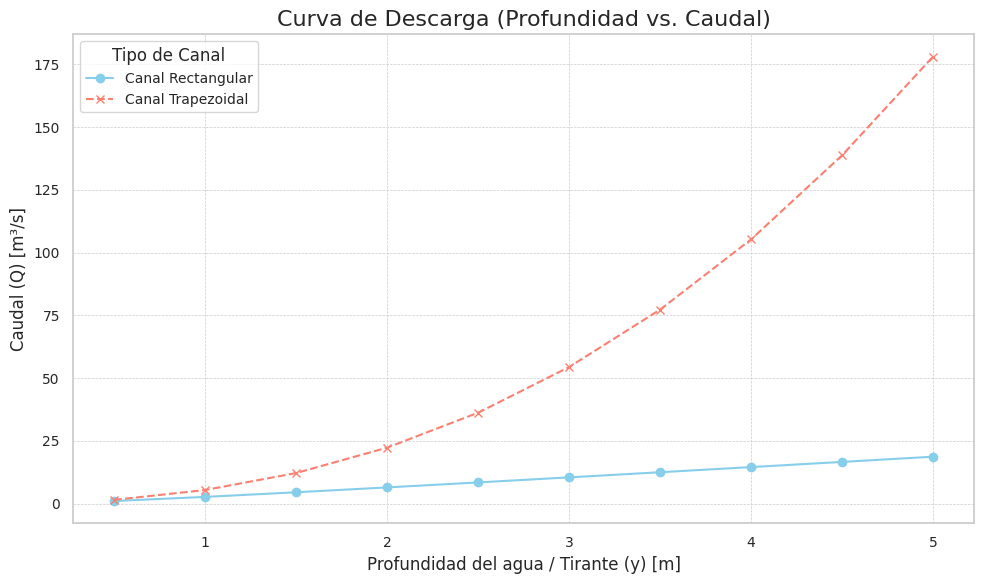

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 2 (Matplotlib Básico) y Paso 3 (Personalización con Seaborn)

# Configuración de estilo con Seaborn para un aspecto profesional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Graficar la curva para el canal rectangular
plt.plot(profundidades, caudales_rect, label='Canal Rectangular', marker='o', linestyle='-', color='skyblue')

# Graficar la curva para el canal trapezoidal
plt.plot(profundidades, caudales_trap, label='Canal Trapezoidal', marker='x', linestyle='--', color='salmon')

# Personalización del gráfico
plt.title('Curva de Descarga (Profundidad vs. Caudal)', fontsize=16)
plt.xlabel('Profundidad del agua / Tirante (y) [m]', fontsize=12)
plt.ylabel('Caudal (Q) [m³/s]', fontsize=12)
plt.legend(title='Tipo de Canal', fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Análisis de la Curva de Descarga

Observa la gráfica generada que compara el caudal para un canal rectangular y uno trapezoidal a diferentes profundidades.

**Pregunta para el estudiante:** ¿Por qué la curva del canal trapezoidal crece más rápido que la del rectangular a medida que aumenta la profundidad?

**(Pista: Piensa en cómo se expande el área mojada en cada tipo de canal a medida que el nivel del agua sube).**

Inserta una nueva celda de texto a continuación y escribe tu análisis.

### Discrepancia en los Resultados

Al comparar los resultados obtenidos de la simulación de Python con los valores proporcionados en la tabla del notebook proporcionado, se observa que no concuerdan completamente. Si bien la estructura y las variables consideradas son las mismas, existen diferencias notables en los caudales calculados para algunas profundidades.

Es importante revisar los siguientes puntos para identificar la causa de estas diferencias:

*   **Constantes:** Asegurarse de que el coeficiente de rugosidad de Manning ($n$), la pendiente ($S$) y el ancho de la base ($b$) sean exactamente los mismos en ambos cálculos.
*   **Fórmulas de Geometría:** Confirmar que las fórmulas para el área ($A$) y el perímetro mojado ($P$) se apliquen correctamente para cada tipo de canal (rectangular y trapezoidal).
*   **Orden de Operaciones y Redondeo:** Verificar el orden de las operaciones matemáticas y el nivel de precisión o redondeo utilizado en cada paso de los cálculos, ya que pequeñas variaciones pueden acumularse y generar diferencias significativas en el resultado final del caudal.

Estas diferencias pueden indicar una pequeña variación en los parámetros de entrada o en la implementación de las fórmulas. Se recomienda una verificación minuciosa de cada paso en el cálculo para asegurar la coherencia.